In [80]:
import random
import ast
import inspect
import instructor
import json

import openai

from pydantic import BaseModel, Field
from jinja2 import Template
from typing import Literal, Dict, Any, Annotated, List
from operator import add

from IPython.display import Image, display

from qdrant_client import QdrantClient
from qdrant_client.models import (
    Filter,
    FieldCondition,
    MatchValue,
    VectorParams,
    Distance,
    SparseVectorParams,
    Modifier,
    PayloadSchemaType,
    Document,
    PointStruct,
    Prefetch,
    FusionQuery,
    RrfQuery,
    Rrf
)

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.types import Send

from langchain_core.messages import AIMessage, HumanMessage, ToolMessage, convert_to_openai_messages, convert_to_messages

from langsmith import traceable

from utils.utils import get_tool_descriptions, format_ai_message

In [6]:
qdrant_client = QdrantClient(url="http://localhost:6333")

### Retrieval

In [11]:
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )
    return response.data[0].embedding

In [12]:
def retrieve_data(query, qdrant_client, k=5):
   
    query_embedding = get_embedding(query)
    results = qdrant_client.query_points(
        collection_name="Amazon-items-collection-01-hybrid-search",
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="text-embedding-3-small",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=query,
                    model="qdrant/bm25",
                ),
                using="bm25",
                limit=20
            )
        ],
        query=RrfQuery(rrf=Rrf(weights=[1,1])),
        limit=k
    )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []
    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_context": retrieved_context,
        "similarity_scores": similarity_scores,
        "retrieved_context_ratings": retrieved_context_ratings
    }

In [15]:
QUERY = "Can I get a fiction book?"

In [19]:
answer = retrieve_data(QUERY, qdrant_client, k=10)
answer

{'retrieved_context_ids': ['0008436304',
  '0593598830',
  'B09X3K5V18',
  '0931779863',
  '1732084297',
  '1954332319',
  'B0C5KNP2RC',
  '1635420741',
  '1954325428',
  'B0BD31V5YG'],
 'retrieved_context': ["An Island at War A moving historical novel inspired by the German occupation of the Channel Islands during WW2. This is a story of courage, resilience and everyday acts of defiance from ordinary people forced to live in an extraordinary time. The USA Today bestseller! June 1940 While her little sister Rosie is sent to the UK to keep her safe from the invading German army, Estelle Le Maistre is left behind on Jersey to help her grandmother run the family farm. When the Germans occupy the island, everything changes and Estelle and the islanders must face the reality of life under Nazi rule. Interspersed with diary entries from Rosie back on the mainland, the novel is also inspired by real life stories from the author’s own family who were both on the island during the occupation an

### Multi-Intent Questions

In [20]:
QUERY_MULTI = "Can I get a kids book for my sone and a fiction book for me?"

In [21]:
answer_multi = retrieve_data(QUERY_MULTI, qdrant_client, k=10)
answer_multi

{'retrieved_context_ids': ['1960156004',
  '0316570605',
  'B0B2TW9M6L',
  'B09TF1PB7G',
  '0593598830',
  '1732084297',
  '1728250366',
  '0008436304',
  '0931779863',
  'B0C4MGCWQ5'],
 'retrieved_context': ['My Mom Never Farts: A Hilarious, Rhyming, Read Aloud Picture Book for Kids and Adults- A Perfect Gift for Any Occasion (Hilarious "NEVER" Series) Everyone knows that moms never fart!!! So what could go wrong in this super silly book? Charlie has a huge problem!!! He knows that his mom would never, ever fart!!! But, his cat keeps acting like she farts all of the time!!! Will Charlie get down to the bottom of it? Join him and his hilarious cat on their super silly adventure!!! Introducing MY MOM NEVER FARTS - A witty, clever, and incredibly warm and funny book that will have your kids wanting to read it again and again!!! And, Mom will get plenty of chuckles as well... Why does this book rock? The Illustrations are HILARIOUS!!! A mom with two daughters who have the same super funny

In [22]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

In [24]:
def query_expansion_node(query: str) -> dict:
    prompt_template = """You are a query expansion module in a shopping assitant. Your job is to rewrite a customers query into distinct statements for semantic product search.

## Instructions

- Expand the question into 1-5 concise statements.
- Each statement should capture a separate product or attirbute from the query.
- Use natural product-description language.
- Do not produce multiple statements that express the same intent.

## Examples

Question: "Can I get finction book for me and a kids book for my son?"
Statements:
- "Fiction book"
- "Kids book"

Question: "I need a warm winter jacket for hiking"
Statements:
- "Insulated winter jacket"
- "Hiking outerwear for cold weather"

Question: "Do you have any toys"
Statements:
- "Toys"

<question>
{{ query }}
</question>
    """

    prompt = Template(prompt_template).render(query=query)

    client = instructor.from_provider(
        "openai/gpt-4.1-mini"
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {
                "role": "system",
                "content": prompt
            }
        ],
        response_model=QueryExpandResponse
    )

    return {
        "queries": response.statements
    }

In [25]:
expansion_response = query_expansion_node(QUERY_MULTI)

In [26]:
expansion_response

{'queries': ['Kids book', 'Fiction book']}

## LangGraph

### Query Expansion (Sequential Execution)

In [42]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[str], add] = []
    initial_query: str = ""
    answer: str = ""

### Query Expansion / Rewriting Node

In [43]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

@traceable(
    name="expand_query",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def query_expansion_node(state: State) -> dict:

    preprocessed_context = "\n".join(state.retrieved_context)

    prompt_template = """You are a query expansion module in a shopping assitant. Your job is to rewrite a customers query into distinct statements for semantic product search.

## Instructions

- Expand the question into 1-5 concise statements.
- Each statement should capture a separate product or attirbute from the query.
- Use natural product-description language.
- Do not produce multiple statements that express the same intent.

## Examples

Question: "Can I get finction book for me and a kids book for my son?"
Statements:
- "Fiction book"
- "Kids book"

Question: "I need a warm winter jacket for hiking"
Statements:
- "Insulated winter jacket"
- "Hiking outerwear for cold weather"

Question: "Do you have any toys"
Statements:
- "Toys"

<question>
{{ query }}
</question>
    """

    prompt = Template(prompt_template).render(query=state.initial_query)

    client = instructor.from_provider(
        "openai/gpt-4.1-mini"
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {
                "role": "system",
                "content": prompt
            }
        ],
        response_model=QueryExpandResponse
    )

    return {
        "expanded_query": response.statements
    }

### Retriever Node

In [56]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={"ls_provider": "openai", "ls_model": "text_embedding_3_small"}
)
def get_embedding(text, model='text-embedding-3-small'):

    response = openai.embeddings.create(
        input=text,
        model=model
    )

    return response.data[0].embedding

@traceable(
    name="retrieve_data",
    run_type='retriever'
)
def retrieve_data(query, qdrant_client, k=5):
   
    query_embedding = get_embedding(query)
    results = qdrant_client.query_points(
        collection_name="Amazon-items-collection-01-hybrid-search",
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="text-embedding-3-small",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=query,
                    model="qdrant/bm25",
                ),
                using="bm25",
                limit=20
            )
        ],
        query=RrfQuery(rrf=Rrf(weights=[1,1])),
        limit=k
    )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []
    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    formatted_context = ""
    for id, chunck, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunck}\n"

    return formatted_context

@traceable(
    name="retriever_node",
    run_type="retriever"
)
def retriever_node(state: State) -> dict:

    retrieved_context = []
    for query in state.expanded_query:
        retrieved_context.append(retrieve_data(query, qdrant_client, k=5))
        
    return {
         "retrieved_context": retrieved_context
    }

### Agregator Node

In [57]:
class AggregatorResponse(BaseModel):
    answer: str

In [66]:
@traceable(
    name="aggregator",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def aggregator_node(state: State) -> dict:

    preprocessed_context = "\n".join(state.retrieved_context)

    prompt_template = """You are a shopping assistant that can answer questions about the products in stock.

You will be given a question and a list of context.

Instructions:
- You need to answer the question based on the provided context only.
- Never use word context and refer to it as the available products.
- The answer to the question should contain detailed information about the product and returend with detailed specification in bullet points.

## Context:

{{ preprocessed_context }}

## Question:

{{ question }}
    """

    prompt = Template(prompt_template).render(
        preprocessed_context=state.retrieved_context,
        question=state.initial_query
        )

    client = instructor.from_provider(
        "openai/gpt-4.1-mini"
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {
                "role": "system",
                "content": prompt
            }
        ],
        response_model=AggregatorResponse
    )

    return {
        "expanded_query": response.answer
    }

In [67]:
workflow = StateGraph(State)

workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)

workflow.add_edge(START, "query_expansion_node")
workflow.add_edge("query_expansion_node", "retriever_node")
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

In [68]:
initial_state = {
    "initial_query": QUERY_MULTI
}

In [69]:
result = graph.invoke(initial_state)
result

{'expanded_query': 'For your son, there are several excellent kids books available:\n1. "Easter Basket Stuffers: I Spy Easter Book for Kids" – A fun Easter activity book for toddlers and preschoolers packed with over 100 cartoon graphics including bunnies, eggs, chickens, angels, and Bible themes. Perfect for ages 2-5, it features great Easter patterns and is designed for little hands.\n   - Over 100 pages of fun\n   - Easter themed with engaging designs\n   - Perfect for toddlers and preschoolers (ages 2+)\n\n2. "Merry Christmas Coloring Book for Kids" – A Christmas themed coloring book for kids ages 4-8. It includes 30 festive designs, high quality white paper, is marker safe with single-sided pages, and has a glossy premium cover.\n   - 30 Christmas designs\n   - Marker safe, single-sided pages\n   - Size: 8.5 x 11 inches\n\n3. "The Ultimate Space Coloring Book For Kids" – Contains 50 space-themed drawings like planets, rockets, astronauts, and aliens. Suitable for kids ages 3-8, wi

In [77]:
print(result["expanded_query"])

For your son, there are several excellent kids books available:
1. "Easter Basket Stuffers: I Spy Easter Book for Kids" – A fun Easter activity book for toddlers and preschoolers packed with over 100 cartoon graphics including bunnies, eggs, chickens, angels, and Bible themes. Perfect for ages 2-5, it features great Easter patterns and is designed for little hands.
   - Over 100 pages of fun
   - Easter themed with engaging designs
   - Perfect for toddlers and preschoolers (ages 2+)

2. "Merry Christmas Coloring Book for Kids" – A Christmas themed coloring book for kids ages 4-8. It includes 30 festive designs, high quality white paper, is marker safe with single-sided pages, and has a glossy premium cover.
   - 30 Christmas designs
   - Marker safe, single-sided pages
   - Size: 8.5 x 11 inches

3. "The Ultimate Space Coloring Book For Kids" – Contains 50 space-themed drawings like planets, rockets, astronauts, and aliens. Suitable for kids ages 3-8, with single-sided pages and a lar

## Query Expansion - Parallel Execution

In [78]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[str], add] = []
    initial_query: str = ""
    answer: str = ""
    query: str = ""
    k: int = 10

### Query Expansion / Rewriting Node

In [79]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

@traceable(
    name="expand_query",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def query_expansion_node(state: State) -> dict:

    preprocessed_context = "\n".join(state.retrieved_context)

    prompt_template = """You are a query expansion module in a shopping assitant. Your job is to rewrite a customers query into distinct statements for semantic product search.

## Instructions

- Expand the question into 1-5 concise statements.
- Each statement should capture a separate product or attirbute from the query.
- Use natural product-description language.
- Do not produce multiple statements that express the same intent.

## Examples

Question: "Can I get finction book for me and a kids book for my son?"
Statements:
- "Fiction book"
- "Kids book"

Question: "I need a warm winter jacket for hiking"
Statements:
- "Insulated winter jacket"
- "Hiking outerwear for cold weather"

Question: "Do you have any toys"
Statements:
- "Toys"

<question>
{{ query }}
</question>
    """

    prompt = Template(prompt_template).render(query=state.initial_query)

    client = instructor.from_provider(
        "openai/gpt-4.1-mini"
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {
                "role": "system",
                "content": prompt
            }
        ],
        response_model=QueryExpandResponse
    )

    return {
        "expanded_query": response.statements
    }

In [83]:
def query_expand_conditional_edge(state: State) -> list:

    send_messages = []

    for query in state.expanded_query:
        send_messages.append(
            Send(
                "retriever_node",
                {
                    "query": query,
                    "k": state.k
                }
            )
        )
    
    return send_messages


### Retriever Node

In [111]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={"ls_provider": "openai", "ls_model": "text_embedding_3_small"}
)
def get_embedding(text, model='text-embedding-3-small'):

    response = openai.embeddings.create(
        input=text,
        model=model
    )

    return response.data[0].embedding

@traceable(
    name="retriever_node",
    run_type='retriever'
)
def retriever_node(state: State) -> dict:

    qdrant_client = QdrantClient(url="http://localhost:6333")
    query = state["query"]
   
    query_embedding = get_embedding(query)
    results = qdrant_client.query_points(
        collection_name="Amazon-items-collection-01-hybrid-search",
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="text-embedding-3-small",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=query,
                    model="qdrant/bm25",
                ),
                using="bm25",
                limit=20
            )
        ],
        query=RrfQuery(rrf=Rrf(weights=[1,1])),
        limit=state["k"]
    )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []
    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    formatted_context = ""
    for id, chunck, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunck}\n"

    return {
        "retrieved_context": [formatted_context]
    }

### Agregator Node

In [112]:
class AggregatorResponse(BaseModel):
    answer: str

In [113]:
@traceable(
    name="aggregator",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def aggregator_node(state: State) -> dict:

    preprocessed_context = "\n".join(state.retrieved_context)

    prompt_template = """You are a shopping assistant that can answer questions about the products in stock.

You will be given a question and a list of context.

Instructions:
- You need to answer the question based on the provided context only.
- Never use word context and refer to it as the available products.
- The answer to the question should contain detailed information about the product and returend with detailed specification in bullet points.

## Context:

{{ preprocessed_context }}

## Question:

{{ question }}
    """

    prompt = Template(prompt_template).render(
        preprocessed_context=state.retrieved_context,
        question=state.initial_query
        )

    client = instructor.from_provider(
        "openai/gpt-4.1-mini"
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {
                "role": "system",
                "content": prompt
            }
        ],
        response_model=AggregatorResponse
    )

    return {
        "expanded_query": response.answer
    }

In [114]:
workflow = StateGraph(State)

workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)

workflow.add_conditional_edges("query_expansion_node", query_expand_conditional_edge)

workflow.add_edge(START, "query_expansion_node")
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

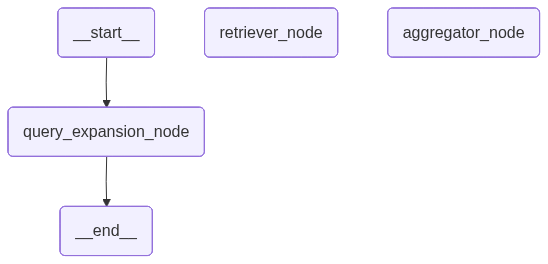

In [115]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [116]:
initial_state = {
    "initial_query": QUERY_MULTI
}

In [117]:
result = graph.invoke(initial_state)
result

{'expanded_query': 'For your son, I recommend the "I Spy Easter Book for Kids" which is an interactive activity book perfect for toddlers and preschoolers ages 2-5. It features over 100 pages with more than 100 cartoon graphics with Easter themes like bunnies, eggs, chickens, angels, and Bible motifs, designed to engage and educate young children. \n\nFor you, I suggest "The Wishing Game: A Novel," an absorbing and whimsical fiction novel about a reclusive bestselling children\'s author who resurfaces with a new book and competition. The story involves themes of hope, love, and a mysterious contest that could change lives. This novel is engaging and great for adults who enjoy intriguing and heartfelt fiction.\n\nDetailed specifications:\n\nI Spy Easter Book for Kids:\n- Age: 2-5 years\n- Over 100 pages\n- Easter-themed cartoon graphics\n- Interactive I Spy format\n- Great for toddlers and preschoolers\n\nThe Wishing Game: A Novel:\n- Genre: Fiction, whimsical novel\n- Themes: Mystery, 

In [118]:
print(result["expanded_query"])

For your son, I recommend the "I Spy Easter Book for Kids" which is an interactive activity book perfect for toddlers and preschoolers ages 2-5. It features over 100 pages with more than 100 cartoon graphics with Easter themes like bunnies, eggs, chickens, angels, and Bible motifs, designed to engage and educate young children. 

For you, I suggest "The Wishing Game: A Novel," an absorbing and whimsical fiction novel about a reclusive bestselling children's author who resurfaces with a new book and competition. The story involves themes of hope, love, and a mysterious contest that could change lives. This novel is engaging and great for adults who enjoy intriguing and heartfelt fiction.

Detailed specifications:

I Spy Easter Book for Kids:
- Age: 2-5 years
- Over 100 pages
- Easter-themed cartoon graphics
- Interactive I Spy format
- Great for toddlers and preschoolers

The Wishing Game: A Novel:
- Genre: Fiction, whimsical novel
- Themes: Mystery, hope, love, childhood stories
- Suit